<a href="https://colab.research.google.com/github/Trishan-Banik/Sampling-_aliasing_and_reconstruction_Objectives/blob/main/Sampling%2C_aliasing_and_reconstruction_Objectives.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:42: SyntaxWarning: invalid escape sequence '\h'
<>:42: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1211/2355925686.py:42: SyntaxWarning: invalid escape sequence '\h'
  ax_time.plot(t_dense, x_rec, 'r-', linewidth=1.5, label='Reconstructed $\hat{x}(t)$')


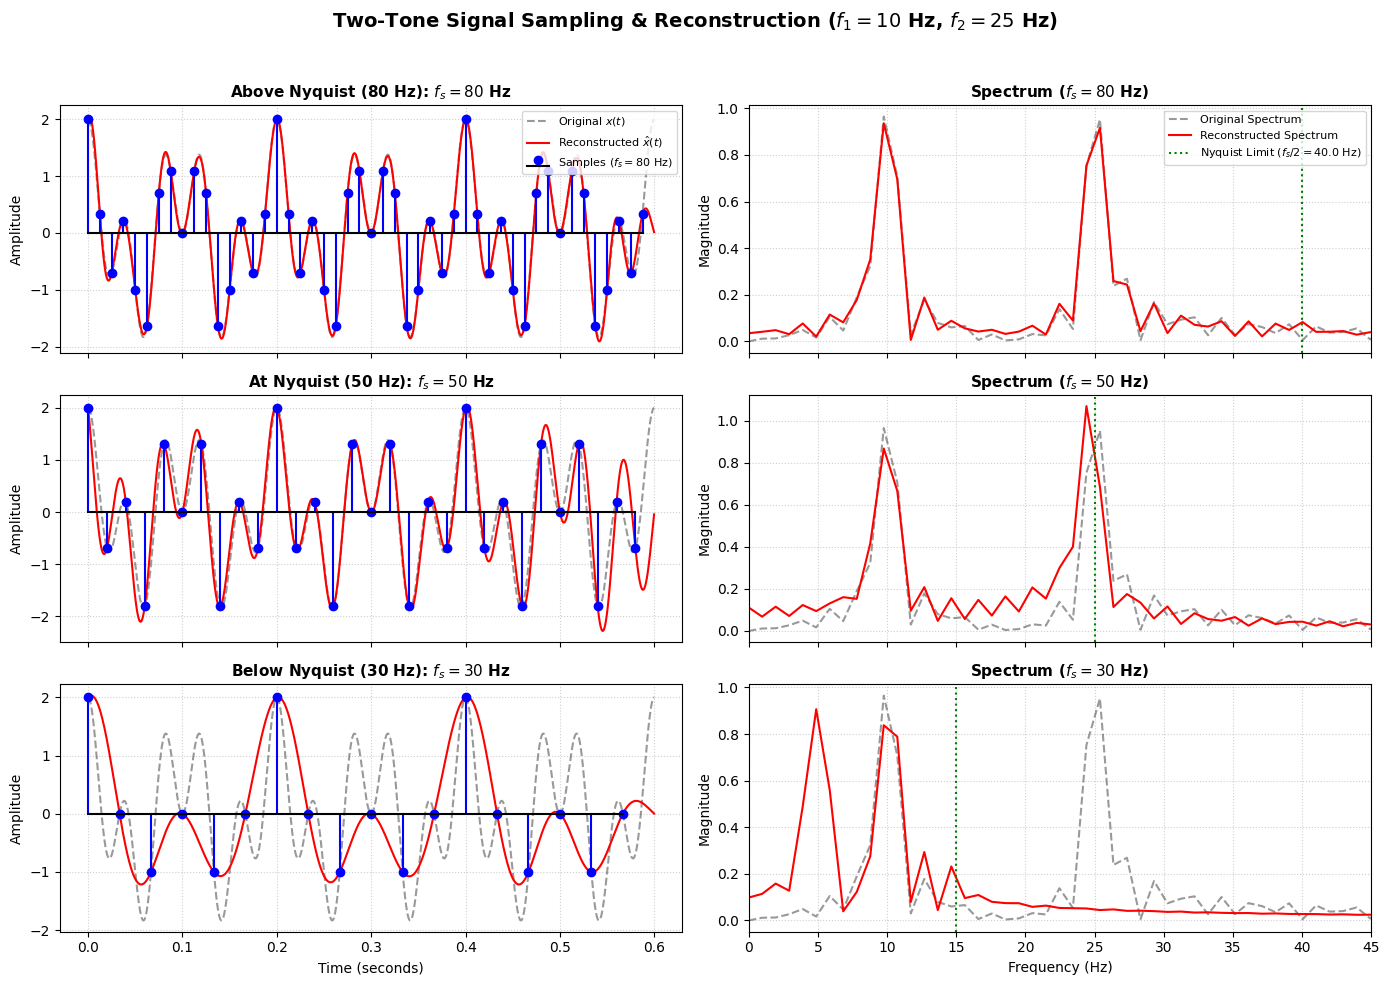

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Physical Parameters & Fine Simulation Grid Setup
f1, f2 = 10.0, 25.0          # Frequencies of two-tone signal in Hz
f_max = max(f1, f2)
f_nyquist = 2 * f_max        # Nyquist rate = 50 Hz

# High resolution grid for continuous signal representation
f_sim = 4000.0                # Simulation sampling rate (dense plotting grid)
t_duration = 0.6              # Duration in seconds
t_dense = np.arange(0, t_duration, 1.0 / f_sim)

# Original continuous-time signal
x_dense = np.cos(2 * np.pi * f1 * t_dense) + np.cos(2 * np.pi * f2 * t_dense)

# 2. Define Sampling Regimes
sampling_cases = {
    'Above Nyquist (80 Hz)': 80.0,
    'At Nyquist (50 Hz)': 50.0,
    'Below Nyquist (30 Hz)': 30.0
}

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex='col')
fig.suptitle('Two-Tone Signal Sampling & Reconstruction ($f_1=10$ Hz, $f_2=25$ Hz)', fontsize=14, fontweight='bold')

for idx, (label, fs) in enumerate(sampling_cases.items()):
    Ts = 1.0 / fs

    # Generate discrete samples
    t_samples = np.arange(0, t_duration, Ts)
    x_samples = np.cos(2 * np.pi * f1 * t_samples) + np.cos(2 * np.pi * f2 * t_samples)

    # 3. Sinc Interpolation (Whittaker-Shannon Reconstruction)
    # Matrix shape: (N_samples, N_dense_points)
    sinc_matrix = np.sinc((t_dense[:, None] - t_samples[None, :]) / Ts)
    x_rec = np.dot(sinc_matrix, x_samples)

    # 4. Time Domain Plotting
    ax_time = axes[idx, 0]
    ax_time.plot(t_dense, x_dense, 'k--', alpha=0.4, label='Original $x(t)$')
    ax_time.plot(t_dense, x_rec, 'r-', linewidth=1.5, label='Reconstructed $\hat{x}(t)$')
    ax_time.stem(t_samples, x_samples, linefmt='b-', markerfmt='bo', basefmt='k-', label=f'Samples ($f_s={int(fs)}$ Hz)')
    ax_time.set_ylabel('Amplitude')
    ax_time.set_title(f'{label}: $f_s = {int(fs)}$ Hz', fontsize=11, fontweight='bold')
    ax_time.grid(True, linestyle=':', alpha=0.6)
    if idx == 0:
        ax_time.legend(loc='upper right', fontsize=8)

    # 5. Frequency Domain Analysis (FFT)
    N_fft = 4096
    freqs = np.fft.rfftfreq(N_fft, d=1.0/f_sim)

    X_orig_mag = np.abs(np.fft.rfft(x_dense, n=N_fft)) / (len(t_dense) / 2)
    X_rec_mag = np.abs(np.fft.rfft(x_rec, n=N_fft)) / (len(t_dense) / 2)

    ax_freq = axes[idx, 1]
    ax_freq.plot(freqs, X_orig_mag, 'k--', alpha=0.4, label='Original Spectrum')
    ax_freq.plot(freqs, X_rec_mag, 'r-', linewidth=1.5, label='Reconstructed Spectrum')
    ax_freq.axvline(fs / 2.0, color='g', linestyle=':', label=f'Nyquist Limit ($f_s/2 = {fs/2:.1f}$ Hz)')
    ax_freq.set_xlim(0, 45)
    ax_freq.set_ylabel('Magnitude')
    ax_freq.set_title(f'Spectrum ($f_s = {int(fs)}$ Hz)', fontsize=11, fontweight='bold')
    ax_freq.grid(True, linestyle=':', alpha=0.6)
    if idx == 0:
        ax_freq.legend(loc='upper right', fontsize=8)

axes[2, 0].set_xlabel('Time (seconds)')
axes[2, 1].set_xlabel('Frequency (Hz)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()